In [2]:
%load_ext autoreload
%autoreload 2

from meta import ROOT_DIR
from bez.segments import segments
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import scipy
import networkx as nx
from bez.topo_graph import * 

from bez.hypergraph import HyperGraph, HYPER, EDGE,NODE

In [ ]:
skeleton = np.array(
    [
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 0, 1, 1, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    ], dtype=bool
)

topo = extract_topology_from_skeleton(skeleton)

print(*topo.edges, sep='\n')
print(topo.edges[(3,1), (4,4),0])

((3, 1), (4, 4), 0)
((4, 4), (3, 7), 0)
((4, 4), (3, 5), 0)
((4, 4), (5, 4), 0)
{'pixels': array([[3, 1],
       [3, 2],
       [3, 3],
       [4, 4]])}


((3, 1), {(4, 4): {0: {'pixels': array([[3, 1],
       [3, 2],
       [3, 3],
       [4, 4]])}}})
((4, 4), {(3, 1): {0: {'pixels': array([[3, 1],
       [3, 2],
       [3, 3],
       [4, 4]])}}, (3, 7): {0: {'pixels': array([[3, 7],
       [3, 6],
       [3, 5],
       [4, 4]])}}, (3, 5): {0: {'pixels': array([[3, 5],
       [4, 4]])}}, (5, 4): {0: {'pixels': array([[4, 4],
       [5, 4]])}}})
((3, 7), {(4, 4): {0: {'pixels': array([[3, 7],
       [3, 6],
       [3, 5],
       [4, 4]])}}})
((3, 5), {(4, 4): {0: {'pixels': array([[3, 5],
       [4, 4]])}}})
((5, 4), {(4, 4): {0: {'pixels': array([[4, 4],
       [5, 4]])}}})
(0, HyperEdge(degree=3, start=(3, 1), end=(4, 4), score=None, edges=[((3, 1), (4, 4), 0)]))
(1, HyperEdge(degree=3, start=(4, 4), end=(3, 7), score=None, edges=[((4, 4), (3, 7), 0)]))
(2, HyperEdge(degree=3, start=(4, 4), end=(3, 5), score=None, edges=[((4, 4), (3, 5), 0)]))
(3, HyperEdge(degree=3, start=(4, 4), end=(5, 4), score=None, edges=[((4, 4), (5, 4), 0)]))
H

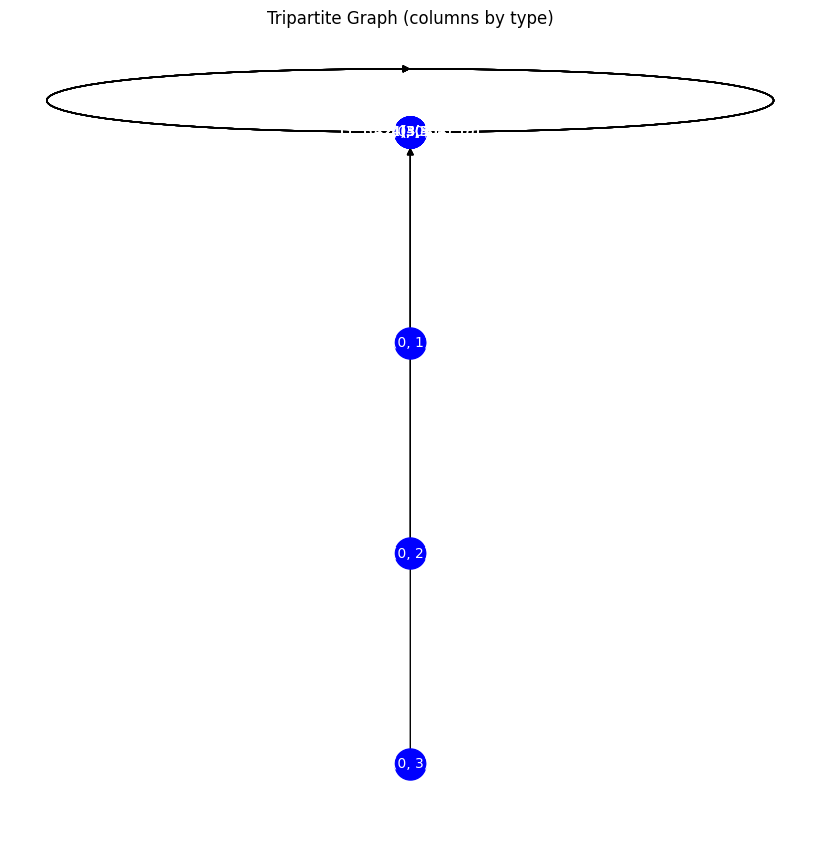

In [ ]:
h = HyperGraph(topo)
print(*list(topo.adjacency()),sep='\n')
print(*h.table.items(),sep="\n" )

tp = h.hyper2edge

# Get node types
nodes = tp.nodes()
# Separate nodes by type
hyper_nodes = [n for n in nodes if n[0] == HYPER]
edge_nodes = [n for n, t in nodes if t == EDGE]

print("Hyper nodes:", hyper_nodes)
# Assign x positions for each type
pos = {}
for i, nodes in enumerate([hyper_nodes, edge_nodes, node_nodes]):
    for j, n in enumerate(nodes):
        print(n)
        pos[n] = (i, -j)


plt.figure(figsize=(8, 8))
nx.draw(tp, pos, with_labels=True, node_size=500, font_size=10, font_color='white', node_color='blue')
plt.title("Tripartite Graph (columns by type)")

plt.show()